## Deep Learning Final Project - AI vs Human Text Classification  

#### Data Preparation & Preprocessing  

##### 1. Import Libraries & Load Dataset
This section loads the dataset and imports all required libraries.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ftfy
import re

pd.set_option('display.max_colwidth', None)

# Load dataset safely using Python engine
df = pd.read_csv("data/AI_human.csv", engine="python", sep=None)

df.head()

text  \
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   Cars. Cars have been around since they became famous in the 1900s, when Henry Ford created and built the first ModelT. Cars have played a major role in our every day lives since then. But now, people are starting to question if limiting car usage would be a good thing. To me, limiting the use of cars might be a good thing to do.\n\nIn like matter of this, article, "In German Suburb, Life Goes On Without Cars," by Elizabeth Rosenthal states, how automobiles are the linchpin of suburbs, where middle class families from either Shanghai or Chicago tend to make their homes. Experts say how this is a huge impediment to current efforts to reduce greenhouse gas emissions from tailpipe. Passenger cars are responsible for 12 percent of greenhouse gas emissions in Europe...and up to 50 percent in some carintensive areas in the United States. Cars are the main reason for the greenhouse gas emissions because of a lot of people driving them around all the time getting where they need to go. Article, "Paris bans driving due to smog," by Robert Duffer says, how Paris, after days of nearrecord pollution, enforced a partial driving ban to clear the air of the global city. It also says, how on Monday, motorist with evennumbered license plates were ordered to leave their cars at home or be fined a 22euro fine 31. The same order would be applied to oddnumbered plates the following day. Cars are the reason for polluting entire cities like Paris. This shows how bad cars can be because, of all the pollution that they can cause to an entire city.\n\nLikewise, in the article, "Carfree day is spinning into a big hit in Bogota," by Andrew Selsky says, how programs that's set to spread to other countries, millions of Columbians hiked, biked, skated, or took the bus to work during a carfree day, leaving streets of this capital city eerily devoid of traffic jams. It was the third straight year cars have been banned with only buses and taxis permitted for the Day Without Cars in the capital city of 7 million. People like the idea of having carfree days because, it allows them to lesson the pollution that cars put out of their exhaust from people driving all the time. The article also tells how parks and sports centers have bustled throughout the city uneven, pitted sidewalks have been replaced by broad, smooth sidewalks rushhour restrictions have dramatically cut traffic and new restaurants and upscale shopping districts have cropped up. Having no cars has been good for the country of Columbia because, it has aloud them to repair things that have needed repairs for 

##### 2. Basic Data Exploration

In [2]:
print("Number of rows:", len(df))
print("\nColumns:", df.columns.tolist())
print("\nData Info:")
df.info()

print("\nClass Distribution:")
print(df['generated'].value_counts())

Number of rows: 487235

Columns: ['text', 'generated']

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 487235 entries, 0 to 487234
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   text       487235 non-null  object 
 1   generated  487235 non-null  float64
dtypes: float64(1), object(1)
memory usage: 7.4+ MB

Class Distribution:
generated
0.0    305797
1.0    181438
Name: count, dtype: int64


##### 3. Handle Missing Values
Check and remove rows with missing text or label values.


In [3]:
print("Missing values before cleaning:")
print(df.isnull().sum())

# Remove rows where text is missing
df = df.dropna(subset=['text', 'generated'])

print("\nMissing values after cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
text         0
generated    0
dtype: int64

Missing values after cleaning:
text         0
generated    0
dtype: int64


##### 4. Remove Duplicates
If duplicate texts exist, they reduce model performance.


In [4]:
before = len(df)
df = df.drop_duplicates(subset=['text'])
after = len(df)

print(f"Duplicates removed: {before - after}")
print(f"New dataset size: {after}")

Duplicates removed: 0
New dataset size: 487235


##### 5. Text Cleaning  


In [5]:
def clean_text(text):
    text = ftfy.fix_text(text)                     # fix unicode
    text = text.lower()                            # lowercase
    text = re.sub(r"http\S+|www\S+", "", text)     # remove URLs
    text = re.sub(r"[^\w\s]", "", text)            # punctuation
    text = re.sub(r"\d+", "", text)                # numbers
    text = re.sub(r"\s+", " ", text).strip()       # extra spaces
    return text

df['clean_text'] = df['text'].astype(str).apply(clean_text)

df[['text', 'clean_text']].head()

text  \
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   Cars. Cars have been around since they became famous in the 1900s, when Henry Ford created and built the first ModelT. Cars have played a major role in our every day lives since then. But now, people are starting to question if limiting car usage would be a good thing. To me, limiting the use of cars might be a good thing to do.\n\nIn like matter of this, article, "In German Suburb, Life Goes On Without Cars," by Elizabeth Rosenthal states, how automobiles are the linchpin of suburbs, where middle class families from either Shanghai or Chicago tend to make their homes. Experts say how this is a huge impediment to current efforts to reduce greenhouse gas emissions from tailpipe. Passenger cars are responsible for 12 percent of greenhouse gas emissions in Europe...and up to 50 percent in some carintensive areas in the United States. Cars are the main reason for the greenhouse gas emissions because of a lot of people driving them around all the time getting where they need to go. Article, "Paris bans driving due to smog," by Robert Duffer says, how Paris, after days of nearrecord pollution, enforced a partial driving ban to clear the air of the global city. It also says, how on Monday, motorist with evennumbered license plates were ordered to leave their cars at home or be fined a 22euro fine 31. The same order would be applied to oddnumbered plates the following day. Cars are the reason for polluting entire cities like Paris. This shows how bad cars can be because, of all the pollution that they can cause to an entire city.\n\nLikewise, in the article, "Carfree day is spinning into a big hit in Bogota," by Andrew Selsky says, how programs that's set to spread to other countries, millions of Columbians hiked, biked, skated, or took the bus to work during a carfree day, leaving streets of this capital city eerily devoid of traffic jams. It was the third straight year cars have been banned with only buses and taxis permitted for the Day Without Cars in the capital city of 7 million. People like the idea of having carfree days because, it allows them to lesson the pollution that cars put out of their exhaust from people driving all the time. The article also tells how parks and sports centers have bustled throughout the city uneven, pitted sidewalks have been replaced by broad, smooth sidewalks rushhour restrictions have dramatically cut traffic and new restaurants and upscale shopping districts have cropped up. Having no cars has been good for the country of Columbia because, it has aloud them to repair things that have needed repairs for 

##### 6. Remove Short or Invalid Texts  

In [6]:
before = len(df)
df = df[df['clean_text'].str.len() > 20]
after = len(df)

print(f"Short texts removed: {before - after}")

Short texts removed: 10


##### 7. Text Length Analysis  
Analyze the word count distribution to understand text complexity.

##### 7.1 Histogram of Word Count  

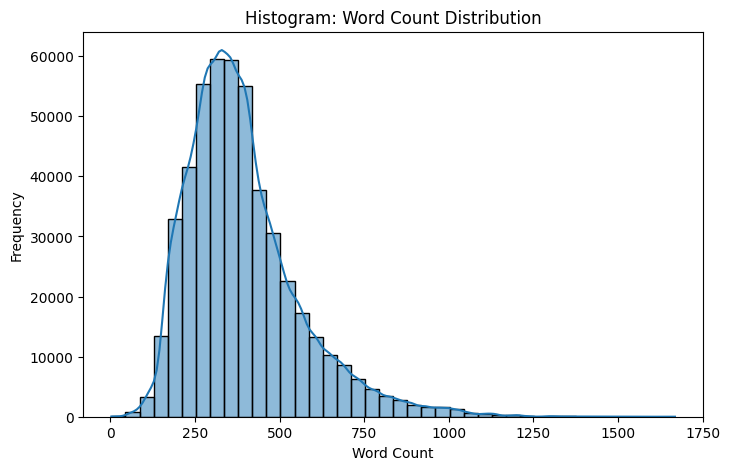

In [7]:
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))

# Histogram
plt.figure(figsize=(8,5))
sns.histplot(df['word_count'], bins=40, kde=True)
plt.title("Histogram: Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()


##### 7.2 Word Count by Class (Human vs AI)

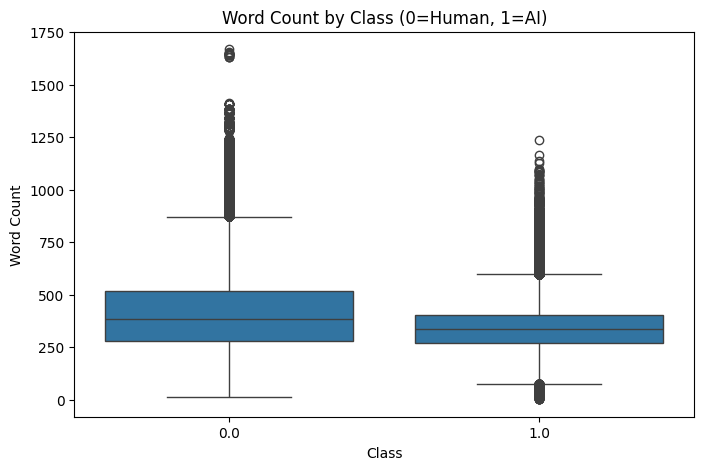

In [9]:
# Boxplot by class
plt.figure(figsize=(8,5))
sns.boxplot(x=df['generated'], y=df['word_count'])
plt.title("Word Count by Class (0=Human, 1=AI)")
plt.xlabel("Class")
plt.ylabel("Word Count")
plt.show()

##### 8. Feature Selection  

Keep the cleaned text and target label.

In [10]:
texts = df['clean_text'].tolist()
labels = df['generated'].astype(int).values

print(texts[0])
print(labels[:10])

cars cars have been around since they became famous in the s when henry ford created and built the first modelt cars have played a major role in our every day lives since then but now people are starting to question if limiting car usage would be a good thing to me limiting the use of cars might be a good thing to do in like matter of this article in german suburb life goes on without cars by elizabeth rosenthal states how automobiles are the linchpin of suburbs where middle class families from either shanghai or chicago tend to make their homes experts say how this is a huge impediment to current efforts to reduce greenhouse gas emissions from tailpipe passenger cars are responsible for percent of greenhouse gas emissions in europeand up to percent in some carintensive areas in the united states cars are the main reason for the greenhouse gas emissions because of a lot of people driving them around all the time getting where they need to go article paris bans driving due to smog by ro

##### 9. Save the Cleaned Dataset  
Useful for reproducibility.


In [11]:
df.to_csv("data/AI_human_cleaned.csv", index=False)
print("Cleaned dataset saved.")

Cleaned dataset saved.


##### 10. Preprocessed Data Summary

In [12]:
print("Final dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nClass distribution after preprocessing:")
print(df['generated'].value_counts())

print("\nExample cleaned text:")
print(df['clean_text'].iloc[0][:300], "...")

Final dataset shape: (487225, 4)
Columns: ['text', 'generated', 'clean_text', 'word_count']

Class distribution after preprocessing:
generated
0.0    305797
1.0    181428
Name: count, dtype: int64

Example cleaned text:
cars cars have been around since they became famous in the s when henry ford created and built the first modelt cars have played a major role in our every day lives since then but now people are starting to question if limiting car usage would be a good thing to me limiting the use of cars might be  ...
